In [ ]:
import numpy as nm
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data_set = pd.read_csv("/content/drive/MyDrive/bill_authentication.csv")

In [ ]:
data_set.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
data_set.tail()

,Variance,Skewness,Curtosis,Entropy,Class
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1
1371,-2.54190,-0.65804,2.6842,1.19520,1


In [ ]:
data_set.shape

(1372, 5)

In [ ]:
data_set.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class'], dtype='object')

In [ ]:
data_set.dtypes

,0
Variance,float64
Skewness,float64
Curtosis,float64
Entropy,float64
Class,int64


In [ ]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [ ]:
data_set.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
X= data_set.iloc[:,:-1].values #separate i/d and dependent variables
Y= data_set.iloc[:,-1].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=0)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(1029, 4)
(343, 4)


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [ ]:
print(X_test)

[[-0.80906482 -2.14852535  2.00805678  0.10249791]
 [ 1.64299264 -0.35291376 -0.2324907   1.09909594]
 [-0.89559047  0.26903381 -0.74542592 -1.25528109]
 ...
 [ 0.28589673  0.41267669  0.21310288  0.68074013]
 [ 1.06867684  0.79339388 -0.45897031  0.35421956]
 [ 1.85277118  0.62760578 -0.85215058  0.45941393]]


In [ ]:
data_set['Class'].value_counts()

,count
Class,
0,762
1,610


In [ ]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion ='log_loss',splitter='random',max_depth=7,max_features='sqrt',random_state=30, min_impurity_decrease=0.00001)
classifier.fit(X_train,Y_train)

DecisionTreeClassifier(criterion='log_loss', max_depth=7, max_features='sqrt',
                       min_impurity_decrease=1e-05, random_state=30,
                       splitter='random')

In [ ]:
print(classifier.classes_)

[0 1]


In [ ]:
classifier.max_features_

2

In [ ]:
classifier.tree_

In [ ]:
classifier.n_outputs_

1

In [ ]:
ypred= classifier.predict(X_test)

In [ ]:
print(ypred)

[1 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 1 1 1 1 0 0
 1 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1 1 1 0 1 1 0 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0
 0 1 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 1 1 1 0 0 0 1 1 0 1 0 1 0 1 0 1 1 1 0
 1 0 0 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 1 0 0 1 0
 0 1 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 1 1 0 1 1 0 1 1 1 1 0 0 0 1 1 0 1 1 0 0
 1 0 1 1 0 0 0 1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0
 0 0 1 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 1 1 0 0 1 1
 0 0 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0
 0 0 1 0 0 1 0 1 1 1 1 0 0 0 0 0 1 0 1 1 1 1 0 0 1 0 1 1 0 1 0 1 1 0 0 0 1
 1 0 1 0 0 1 0 0 0 0]


In [ ]:
print(nm.concatenate((ypred.reshape(len(ypred),1),Y_test.reshape(len(Y_test),1)),1))

[[1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,ypred)
print(cm)

[[175  20]
 [  4 144]]


In [ ]:
print("Accuracy = ",(189+114)/343*100)

Accuracy =  88.33819241982506


In [ ]:
from sklearn.metrics import accuracy_score
print("Test Accuracy = ",accuracy_score(Y_test,ypred))

Test Accuracy =  0.9300291545189504


In [ ]:
from sklearn.metrics import classification_report
print(classification_report,Y_test)

<function classification_report at 0x7f932d8f9440> [1 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 1 0 1 1 1 0 0
 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 0 1 1 1 1 0 1 0 1 0
 0 1 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 1 1 1 0 0 0 1 1 0 1 0 0 0 1 0 1 1 1 0
 1 0 0 1 0 0 0 1 1 0 0 1 1 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 0 0 1 0
 0 1 0 0 0 0 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 1 0 1 1 1 1 0 0 0 1 1 0 1 0 0 0
 1 0 1 1 0 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0
 0 0 0 1 1 0 0 0 0 1 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 0 0 0 0 1 0 1 1 0 0 1 1
 1 0 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 0
 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 1 0 1 0 1 1 0 0 0 1
 1 0 1 0 0 1 0 0 0 0]


In [ ]:
#!pip install -U skilit-learn

In [ ]:
from sklearn.tree import  export_text
text_representation = export_text(classifier)
print(text_representation)

|--- feature_0 <= -1.22
|   |--- feature_2 <= 0.71
|   |   |--- feature_2 <= -0.25
|   |   |   |--- class: 1
|   |   |--- feature_2 >  -0.25
|   |   |   |--- feature_0 <= -1.71
|   |   |   |   |--- class: 1
|   |   |   |--- feature_0 >  -1.71
|   |   |   |   |--- feature_1 <= 0.54
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_1 >  0.54
|   |   |   |   |   |--- feature_1 <= 1.11
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_1 >  1.11
|   |   |   |   |   |   |--- class: 0
|   |--- feature_2 >  0.71
|   |   |--- class: 1
|--- feature_0 >  -1.22
|   |--- feature_1 <= 0.72
|   |   |--- feature_2 <= 2.03
|   |   |   |--- feature_0 <= 1.29
|   |   |   |   |--- feature_3 <= -0.76
|   |   |   |   |   |--- feature_0 <= -0.21
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_0 >  -0.21
|   |   |   |   |   |   |--- feature_1 <= -0.56
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- feature_1 >  -0.56
|   |   |   |

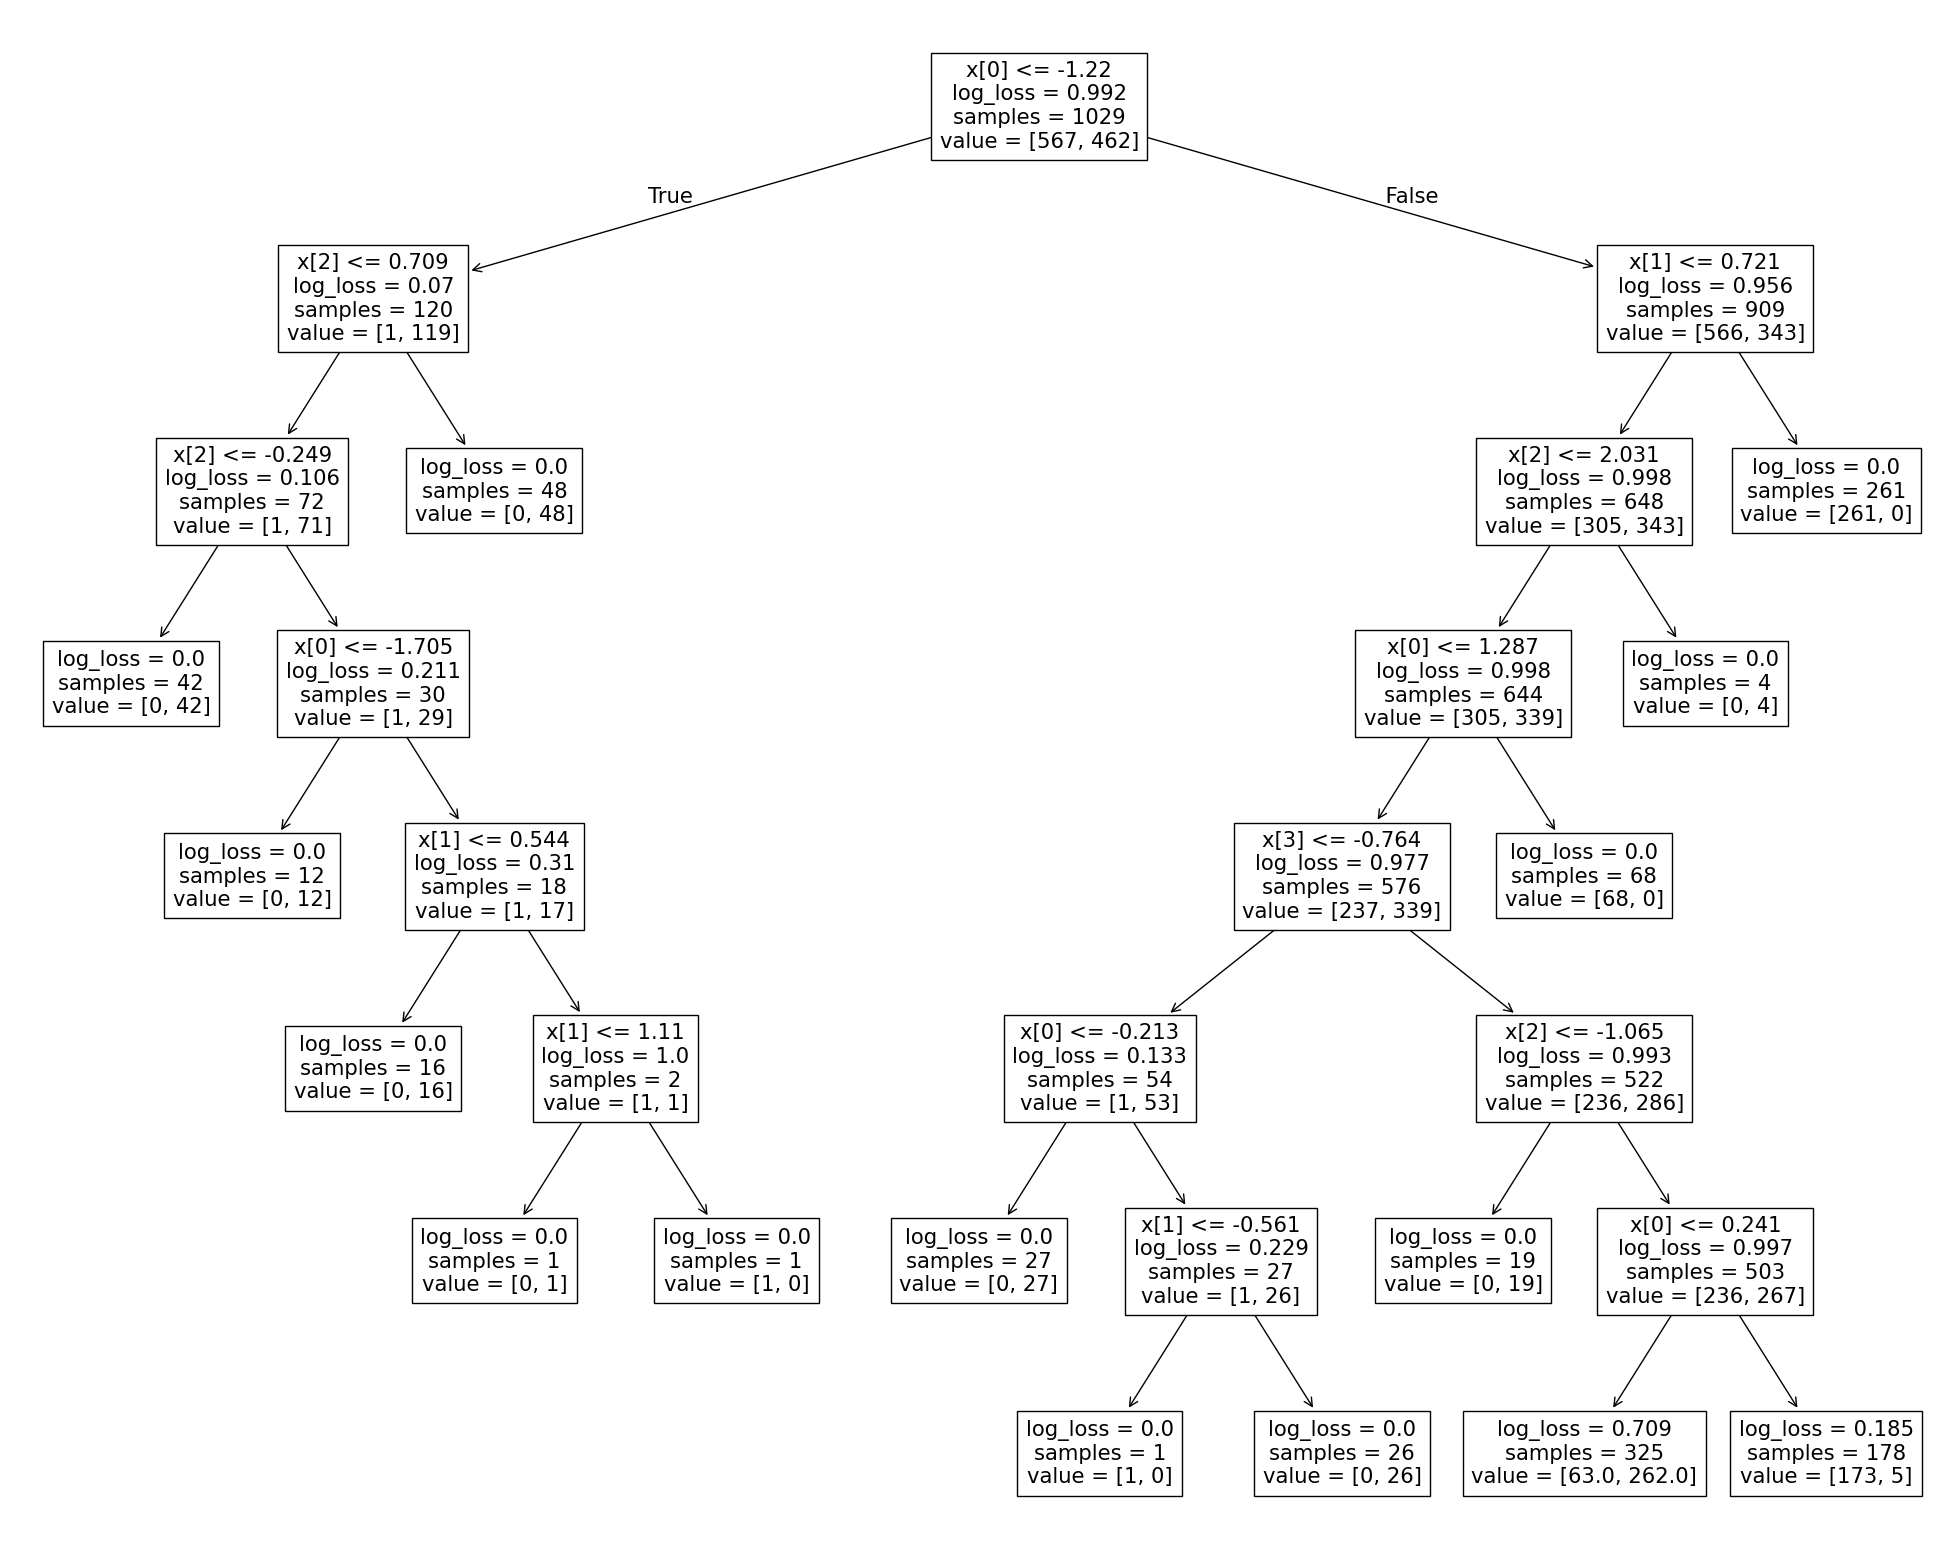

In [ ]:
from sklearn import tree
fig = plt.figure(figsize=(25,20))
tree.plot_tree(classifier)
plt.show()